# EDA complet — Dataset PlantVillage
**Détection des maladies des feuilles de plantes — Projet MLOps & DataOps**

Responsable : Personne 8 (Data Analyst — EDA, Monitoring, Documentation)

## Objectifs de ce notebook
1. Vérifier l'intégrité du dataset (structure, images corrompues, doublons)
2. Analyser la répartition des classes (comptage, déséquilibre)
3. Analyser les propriétés des images (résolution, poids, couleur)
4. Visualiser des exemples représentatifs de chaque classe
5. Proposer un split train/validation/test stratifié
6. Produire un résumé exécutif avec recommandations pour l'équipe ML (P6)

## Sommaire
- 0. Configuration et imports
- 1. Vérification de la structure du dataset
- 2. Comptage des images par classe
- 3. Détection des images corrompues
- 4. Détection des doublons
- 5. Analyse des résolutions (dimensions)
- 6. Analyse du poids des fichiers
- 7. Exemples visuels par classe
- 8. Analyse colorimétrique
- 9. Déséquilibre des classes
- 10. Répartition saine vs malade
- 11. Répartition par plante
- 12. Proposition de split train/val/test stratifié
- 13. Résumé exécutif et recommandations
- 14. Export des résultats (CSV + graphiques)

## 0. Configuration et imports

In [1]:
import os
import hashlib
import random
import warnings
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# --- Paramètres ---
DATA_DIR = Path("../data/raw/PlantVillage")
DOCS_DIR = Path("../docs")
DOCS_DIR.mkdir(exist_ok=True, parents=True)

# Pour l'analyse de résolution/couleur : mettre un nombre (ex. 60) pour échantillonner par classe
# et aller plus vite, ou None pour scanner TOUTES les images (plus long mais complet).
SAMPLE_PER_CLASS = 80

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

print(f"Dossier des données : {DATA_DIR.resolve()}")

Dossier des données : C:\Users\USER\Desktop\plant-disease-detection\data\raw\PlantVillage


## 1. Vérification de la structure du dataset

In [2]:
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Nombre de classes trouvées : {len(classes)}")
for c in classes:
    print(" -", c)

assert len(classes) == 15, "Attention : le nombre de classes n'est pas 15, vérifie qu'il n'y a pas de dossier parasite."

Nombre de classes trouvées : 15
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot
 - Tomato_Spider_mites_Two_spotted_spider_mite
 - Tomato__Target_Spot
 - Tomato__Tomato_YellowLeaf__Curl_Virus
 - Tomato__Tomato_mosaic_virus
 - Tomato_healthy


In [3]:
# Construction de l'inventaire complet : une ligne par image
records = []
for c in tqdm(classes, desc="Inventaire des classes"):
    class_dir = DATA_DIR / c
    for f in class_dir.iterdir():
        if f.suffix in IMG_EXTENSIONS:
            records.append({
                "classe": c,
                "chemin": str(f),
                "nom_fichier": f.name,
                "taille_octets": f.stat().st_size,
            })

inventory = pd.DataFrame(records)
print(f"Total d'images inventoriées : {len(inventory)}")
inventory.head()

Inventaire des classes:   0%|          | 0/15 [00:00<?, ?it/s]

Total d'images inventoriées : 20638


,classe,chemin,nom_fichier,taille_octets
0,Pepper__bell___Bacterial_spot,..\data\raw\PlantVillage\Pepper__bell___Bacter...,0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Sp...,18052
1,Pepper__bell___Bacterial_spot,..\data\raw\PlantVillage\Pepper__bell___Bacter...,006adb74-934f-448f-a14f-62181742127b___JR_B.Sp...,21211
2,Pepper__bell___Bacterial_spot,..\data\raw\PlantVillage\Pepper__bell___Bacter...,00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...,18554
3,Pepper__bell___Bacterial_spot,..\data\raw\PlantVillage\Pepper__bell___Bacter...,01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Sp...,26496
4,Pepper__bell___Bacterial_spot,..\data\raw\PlantVillage\Pepper__bell___Bacter...,0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B....,19517


## 2. Comptage des images par classe

In [4]:
counts_df = inventory.groupby("classe").size().reset_index(name="nb_images")
counts_df = counts_df.sort_values("nb_images", ascending=False).reset_index(drop=True)
counts_df

,classe,nb_images
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208
1,Tomato_Bacterial_spot,2127
2,Tomato_Late_blight,1909
3,Tomato_Septoria_leaf_spot,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676
5,Tomato_healthy,1591
6,Pepper__bell___healthy,1478
7,Tomato__Target_Spot,1404
8,Potato___Early_blight,1000
9,Potato___Late_blight,1000


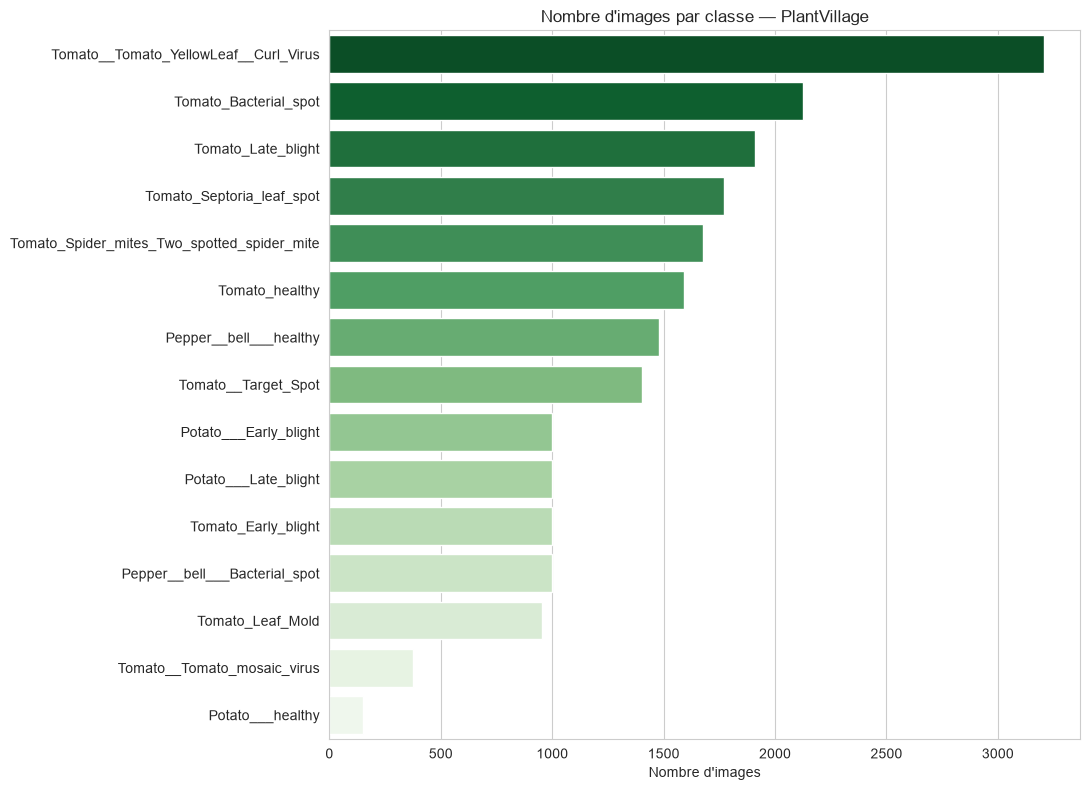

In [5]:
plt.figure(figsize=(11, 8))
sns.barplot(data=counts_df, y="classe", x="nb_images", hue="classe", palette="Greens_r", legend=False)
plt.xlabel("Nombre d'images")
plt.ylabel("")
plt.title("Nombre d'images par classe — PlantVillage")
plt.tight_layout()
plt.savefig(DOCS_DIR / "01_images_per_class.png", dpi=150)
plt.show()

## 3. Détection des images corrompues
On vérifie que chaque fichier est une image valide et lisible (protection avant l'entraînement du modèle).

In [6]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

corrupted = []
for path in tqdm(inventory["chemin"], desc="Vérification des images"):
    if not is_valid_image(path):
        corrupted.append(path)

print(f"Images corrompues ou illisibles trouvées : {len(corrupted)}")
if corrupted:
    for p in corrupted[:20]:
        print(" -", p)
else:
    print("Aucune image corrompue détectée. Le dataset est propre.")

Vérification des images:   0%|          | 0/20638 [00:00<?, ?it/s]

Images corrompues ou illisibles trouvées : 0
Aucune image corrompue détectée. Le dataset est propre.


## 4. Détection des doublons (hash exact des fichiers)

In [7]:
def file_hash(path, block_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

hash_to_paths = defaultdict(list)
for path in tqdm(inventory["chemin"], desc="Calcul des empreintes (hash)"):
    hash_to_paths[file_hash(path)].append(path)

duplicate_groups = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
n_duplicates = sum(len(paths) - 1 for paths in duplicate_groups.values())

print(f"Groupes de doublons trouvés : {len(duplicate_groups)}")
print(f"Nombre d'images en trop (doublons) : {n_duplicates}")

for h, paths in list(duplicate_groups.items())[:5]:
    print("\nDoublon :")
    for p in paths:
        print("  -", p)

Calcul des empreintes (hash):   0%|          | 0/20638 [00:00<?, ?it/s]

Groupes de doublons trouvés : 14
Nombre d'images en trop (doublons) : 14

Doublon :
  - ..\data\raw\PlantVillage\Tomato_Late_blight\1a69b38b-c4eb-42c4-9584-bcb14fb8db0c___GHLB2 Leaf 9011.JPG
  - ..\data\raw\PlantVillage\Tomato_Late_blight\2c47b891-3c97-48f1-a2cc-5aa53d3a1148___GHLB2 Leaf 9011.JPG

Doublon :
  - ..\data\raw\PlantVillage\Tomato_Late_blight\3fae9c64-18f0-4a67-9f97-554248bb1bed___GHLB_PS Leaf 24 Day 16.jpg
  - ..\data\raw\PlantVillage\Tomato_Late_blight\5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS Leaf 24 Day 16.jpg

Doublon :
  - ..\data\raw\PlantVillage\Tomato_Late_blight\48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS Leaf 23.7 Day 13.jpg
  - ..\data\raw\PlantVillage\Tomato_Late_blight\bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS Leaf 23.7 Day 13.jpg

Doublon :
  - ..\data\raw\PlantVillage\Tomato_Late_blight\5688ea99-c949-41d0-bbab-9cbf0ffb8bcd___GHLB2 Leaf 8677.JPG
  - ..\data\raw\PlantVillage\Tomato_Late_blight\e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 Leaf 8677

## 5. Analyse des résolutions (dimensions des images)
Analyse faite sur un échantillon par classe (`SAMPLE_PER_CLASS`) pour rester rapide. Mets `SAMPLE_PER_CLASS = None` en haut du notebook pour scanner l'intégralité du dataset (plus long).

In [8]:
random.seed(42)

def get_sample(df, n):
    if n is None or n >= len(df):
        return df
    return df.sample(n, random_state=42)

sample_rows = pd.concat(
    [get_sample(inventory[inventory["classe"] == c], SAMPLE_PER_CLASS) for c in classes],
    ignore_index=True
)

dims = []
for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc="Lecture des dimensions"):
    img = cv2.imread(row["chemin"])
    if img is not None:
        h, w = img.shape[:2]
        dims.append({"classe": row["classe"], "height": h, "width": w, "ratio": round(w / h, 2)})

dims_df = pd.DataFrame(dims)
print(f"Images analysées pour la résolution : {len(dims_df)}")
dims_df.describe()

Lecture des dimensions:   0%|          | 0/1200 [00:00<?, ?it/s]

Images analysées pour la résolution : 1200


,height,width,ratio
count,1200.0,1200.0,1200.0
mean,256.0,256.0,1.0
std,0.0,0.0,0.0
min,256.0,256.0,1.0
25%,256.0,256.0,1.0
50%,256.0,256.0,1.0
75%,256.0,256.0,1.0
max,256.0,256.0,1.0


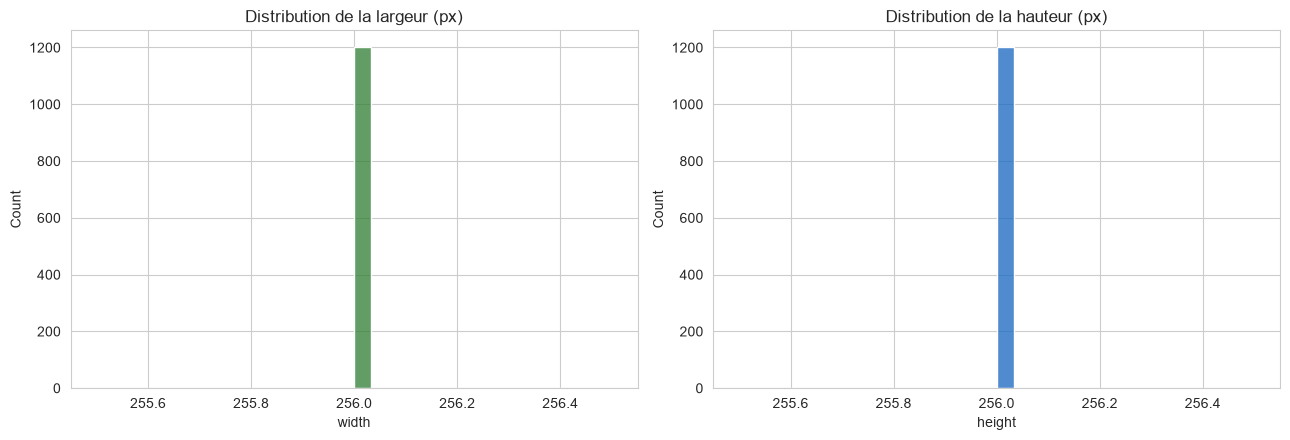

Résolution la plus fréquente : (np.int64(256), np.int64(256))


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(dims_df["width"], bins=30, ax=axes[0], color="#2e7d32")
axes[0].set_title("Distribution de la largeur (px)")
sns.histplot(dims_df["height"], bins=30, ax=axes[1], color="#1565c0")
axes[1].set_title("Distribution de la hauteur (px)")
plt.tight_layout()
plt.savefig(DOCS_DIR / "02_resolution_distribution.png", dpi=150)
plt.show()

print(f"Résolution la plus fréquente : {dims_df.groupby(['width','height']).size().idxmax()}")

## 6. Analyse du poids des fichiers

Statistiques de la taille des fichiers (Ko) :
count    20638.000000
mean        16.193899
std          4.503844
min          3.359375
25%         12.754395
50%         16.601074
75%         19.378662
max        118.800781
Name: taille_ko, dtype: float64

Taille totale du dataset : 326.4 MB


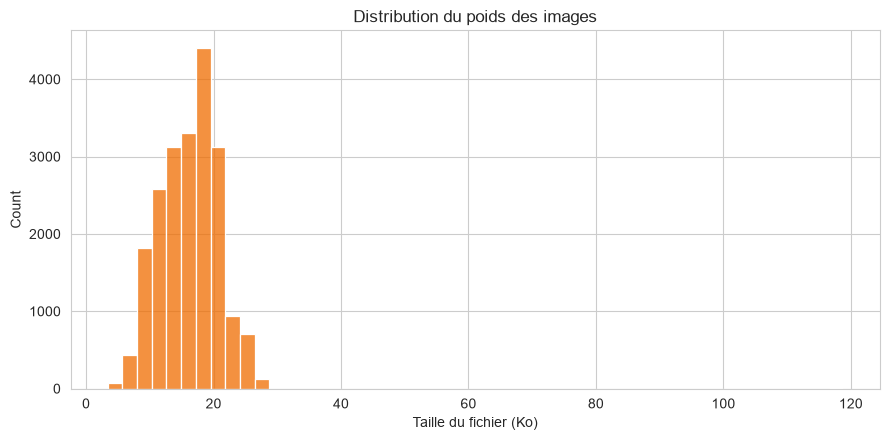

In [10]:
inventory["taille_ko"] = inventory["taille_octets"] / 1024

print("Statistiques de la taille des fichiers (Ko) :")
print(inventory["taille_ko"].describe())

print(f"\nTaille totale du dataset : {inventory['taille_octets'].sum() / (1024**2):.1f} MB")

plt.figure(figsize=(9, 4.5))
sns.histplot(inventory["taille_ko"], bins=50, color="#ef6c00")
plt.xlabel("Taille du fichier (Ko)")
plt.title("Distribution du poids des images")
plt.tight_layout()
plt.savefig(DOCS_DIR / "03_file_size_distribution.png", dpi=150)
plt.show()

## 7. Exemples visuels par classe

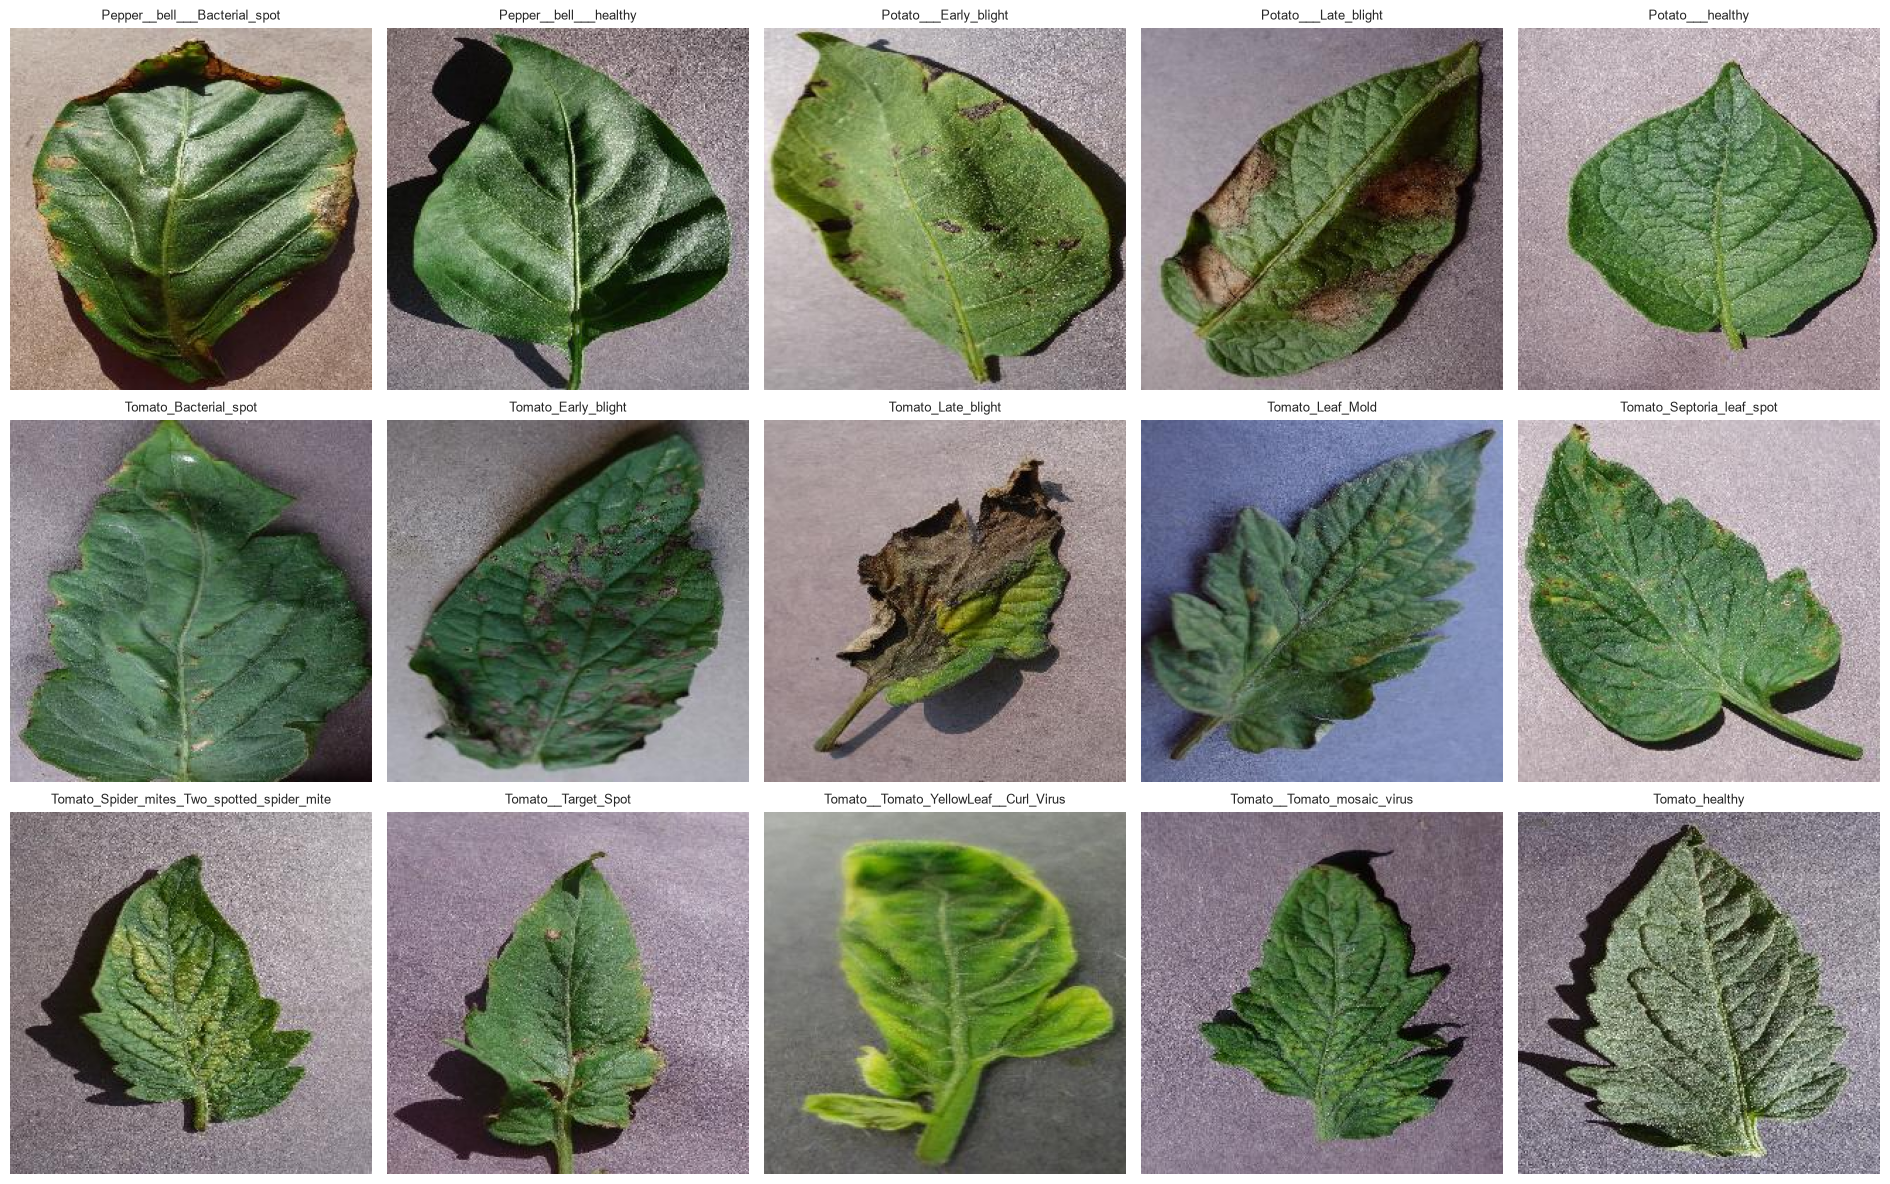

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(19, 12))

for ax, c in zip(axes.flat, classes):
    row = inventory[inventory["classe"] == c].sample(1, random_state=1).iloc[0]
    img = cv2.cvtColor(cv2.imread(row["chemin"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(c, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(DOCS_DIR / "04_examples_per_class.png", dpi=150)
plt.show()

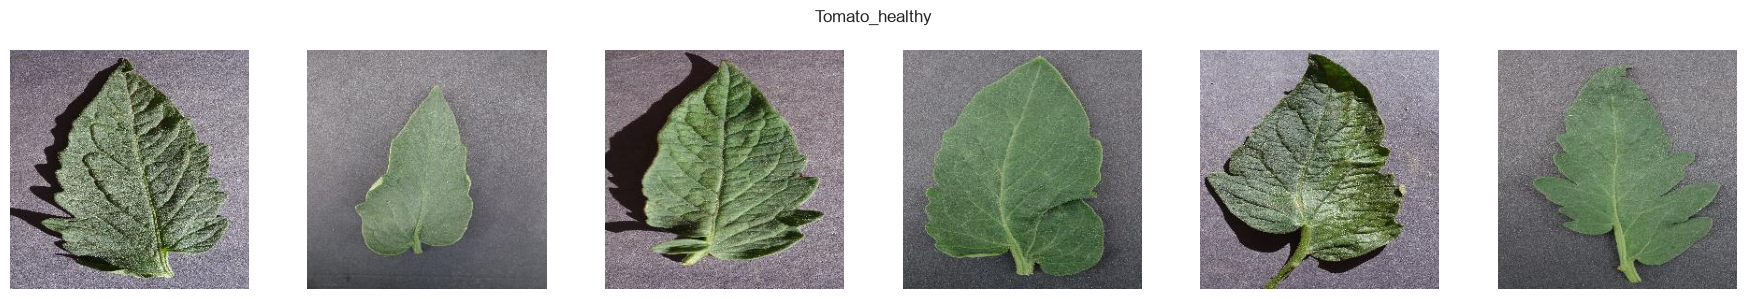

In [12]:
# Grille de plusieurs exemples pour une classe donnée (utile pour repérer la variabilité intra-classe)
def show_class_samples(classe, n=8):
    rows = inventory[inventory["classe"] == classe].sample(min(n, len(inventory[inventory["classe"] == classe])), random_state=1)
    fig, axes = plt.subplots(1, len(rows), figsize=(3 * len(rows), 3))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["chemin"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(classe)
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation :
show_class_samples("Tomato_healthy", n=6)

## 8. Analyse colorimétrique
Couleur moyenne (RGB) et luminosité moyenne par classe — utile pour repérer les classes visuellement proches (risque de confusion pour le modèle) et pour préparer la détection de dérive de P8 plus tard.

In [13]:
color_stats = []
for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc="Analyse colorimétrique"):
    img = cv2.imread(row["chemin"])
    if img is not None:
        mean_bgr = img.mean(axis=(0, 1))
        brightness = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).mean()
        color_stats.append({
            "classe": row["classe"],
            "mean_R": mean_bgr[2], "mean_G": mean_bgr[1], "mean_B": mean_bgr[0],
            "luminosite": brightness,
        })

color_df = pd.DataFrame(color_stats)
color_summary = color_df.groupby("classe")[["mean_R", "mean_G", "mean_B", "luminosite"]].mean().sort_values("luminosite")
color_summary

Analyse colorimétrique:   0%|          | 0/1200 [00:00<?, ?it/s]

,mean_R,mean_G,mean_B,luminosite
classe,,,,
Tomato_Bacterial_spot,103.208470,110.530681,94.250213,106.492138
Tomato_Early_blight,107.645062,111.637127,99.016578,109.001386
Tomato_Late_blight,113.245834,115.019336,102.030655,113.006464
Tomato_Leaf_Mold,110.916665,115.963008,113.702893,114.203129
Potato___Late_blight,116.686867,118.922311,105.755485,116.753447
Tomato__Tomato_mosaic_virus,118.544016,116.067474,116.958949,116.917883
Tomato__Tomato_YellowLeaf__Curl_Virus,114.540875,123.600610,90.442367,117.108678
Tomato_healthy,114.887219,120.029092,111.058923,117.457760
Tomato_Spider_mites_Two_spotted_spider_mite,121.580476,118.694107,107.554598,118.297609


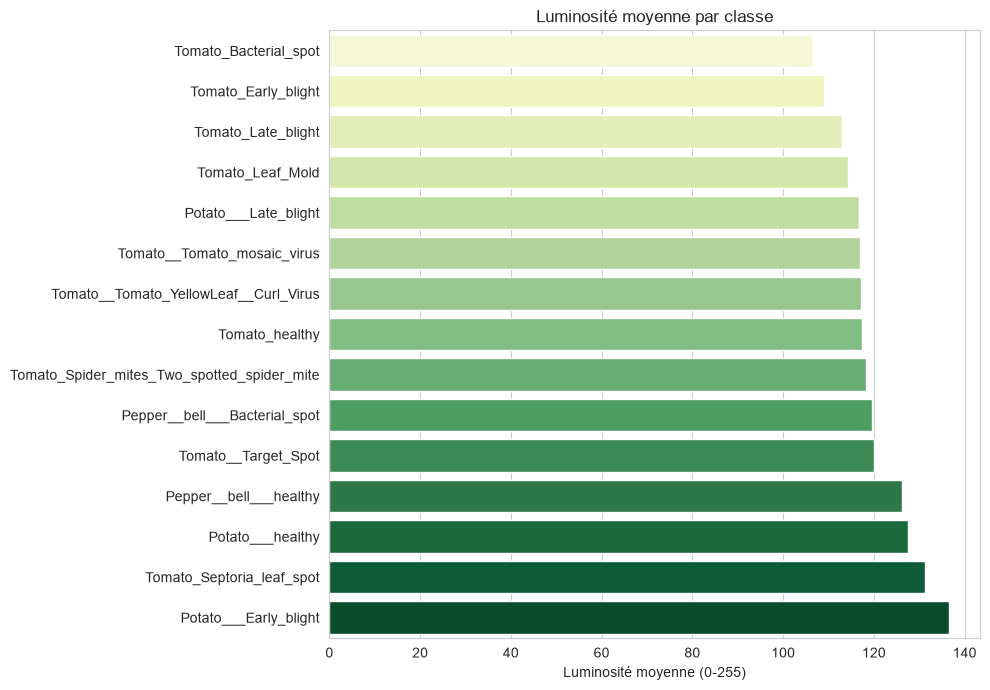

In [14]:
plt.figure(figsize=(10, 7))
sns.barplot(data=color_summary.reset_index(), y="classe", x="luminosite", hue="classe", palette="YlGn", legend=False)
plt.title("Luminosité moyenne par classe")
plt.xlabel("Luminosité moyenne (0-255)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(DOCS_DIR / "05_luminosite_par_classe.png", dpi=150)
plt.show()

## 9. Déséquilibre des classes

In [15]:
min_row = counts_df.loc[counts_df["nb_images"].idxmin()]
max_row = counts_df.loc[counts_df["nb_images"].idxmax()]
ratio = max_row["nb_images"] / min_row["nb_images"]
mean_n = counts_df["nb_images"].mean()
std_n = counts_df["nb_images"].std()

print(f"Classe la plus petite : {min_row['classe']} ({min_row['nb_images']} images)")
print(f"Classe la plus grande : {max_row['classe']} ({max_row['nb_images']} images)")
print(f"Ratio de déséquilibre (max/min) : {ratio:.1f}x")
print(f"Moyenne : {mean_n:.0f} images/classe | Écart-type : {std_n:.0f}")

counts_df["poids_relatif"] = (counts_df["nb_images"] / counts_df["nb_images"].sum() * 100).round(2)
counts_df[["classe", "nb_images", "poids_relatif"]]

Classe la plus petite : Potato___healthy (152 images)
Classe la plus grande : Tomato__Tomato_YellowLeaf__Curl_Virus (3208 images)
Ratio de déséquilibre (max/min) : 21.1x
Moyenne : 1376 images/classe | Écart-type : 744


,classe,nb_images,poids_relatif
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208,15.54
1,Tomato_Bacterial_spot,2127,10.31
2,Tomato_Late_blight,1909,9.25
3,Tomato_Septoria_leaf_spot,1771,8.58
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676,8.12
5,Tomato_healthy,1591,7.71
6,Pepper__bell___healthy,1478,7.16
7,Tomato__Target_Spot,1404,6.80
8,Potato___Early_blight,1000,4.85
9,Potato___Late_blight,1000,4.85


## 10. Répartition plantes saines vs malades

statut
Malade    17417
Saine      3221
Name: nb_images, dtype: int64

Pourcentage malade : 84.4%


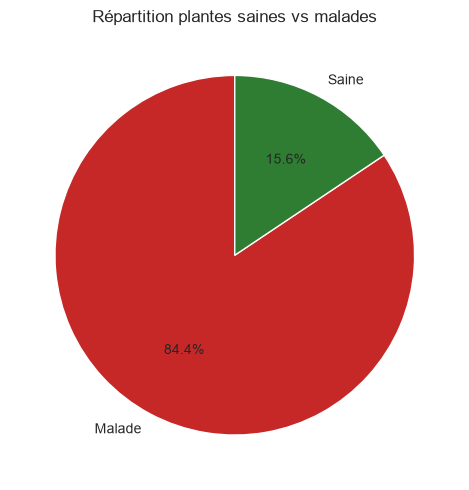

In [16]:
counts_df["statut"] = counts_df["classe"].apply(lambda x: "Saine" if "healthy" in x.lower() else "Malade")

repartition_statut = counts_df.groupby("statut")["nb_images"].sum()
print(repartition_statut)
print(f"\nPourcentage malade : {repartition_statut['Malade'] / repartition_statut.sum() * 100:.1f}%")

plt.figure(figsize=(5, 5))
plt.pie(repartition_statut, labels=repartition_statut.index, autopct="%1.1f%%",
        colors=["#c62828", "#2e7d32"], startangle=90)
plt.title("Répartition plantes saines vs malades")
plt.tight_layout()
plt.savefig(DOCS_DIR / "06_healthy_vs_diseased.png", dpi=150)
plt.show()

## 11. Répartition par plante

plante
Tomato    16011
Pepper     2475
Potato     2152
Name: nb_images, dtype: int64


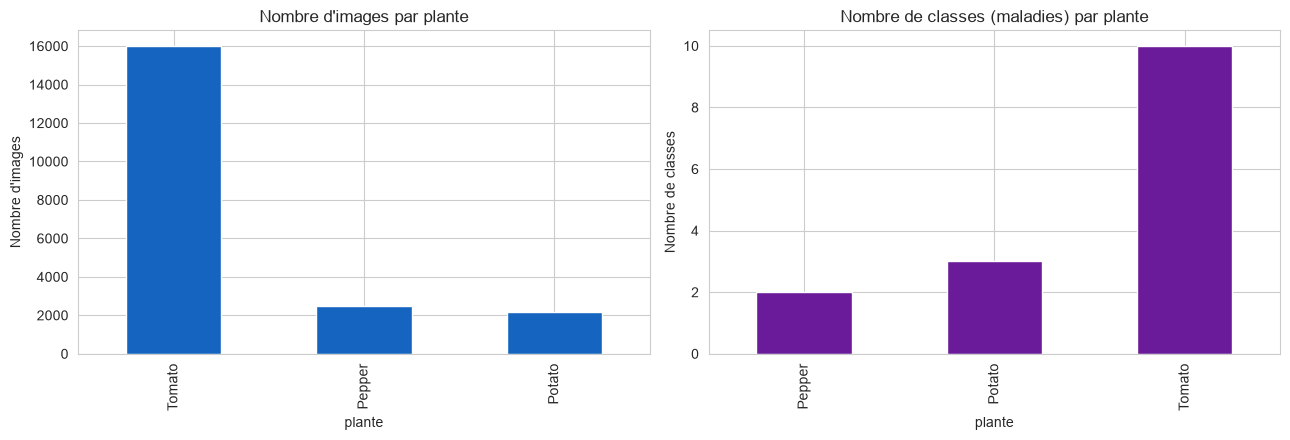

In [17]:
def get_plant(classe):
    c = classe.lower()
    if c.startswith("pepper"):
        return "Pepper"
    elif c.startswith("potato"):
        return "Potato"
    elif c.startswith("tomato"):
        return "Tomato"
    return "Autre"

counts_df["plante"] = counts_df["classe"].apply(get_plant)
repartition_plante = counts_df.groupby("plante")["nb_images"].sum().sort_values(ascending=False)
print(repartition_plante)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
repartition_plante.plot(kind="bar", ax=axes[0], color="#1565c0")
axes[0].set_title("Nombre d'images par plante")
axes[0].set_ylabel("Nombre d'images")

nb_classes_par_plante = counts_df.groupby("plante")["classe"].nunique()
nb_classes_par_plante.plot(kind="bar", ax=axes[1], color="#6a1b9a")
axes[1].set_title("Nombre de classes (maladies) par plante")
axes[1].set_ylabel("Nombre de classes")

plt.tight_layout()
plt.savefig(DOCS_DIR / "07_repartition_par_plante.png", dpi=150)
plt.show()

## 12. Proposition de split train/validation/test stratifié
Simulation d'un split 70% / 15% / 15% en respectant la proportion de chaque classe (stratification), pour que P4/P6 s'en inspirent directement dans le pipeline de préparation.

In [18]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

split_rows = []
for _, r in counts_df.iterrows():
    n = r["nb_images"]
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    n_test = n - n_train - n_val
    split_rows.append({"classe": r["classe"], "train": n_train, "val": n_val, "test": n_test, "total": n})

split_df = pd.DataFrame(split_rows)
print("Split proposé (70/15/15), stratifié par classe :")
split_df

Split proposé (70/15/15), stratifié par classe :


,classe,train,val,test,total
0,Tomato__Tomato_YellowLeaf__Curl_Virus,2245,481,482,3208
1,Tomato_Bacterial_spot,1488,319,320,2127
2,Tomato_Late_blight,1336,286,287,1909
3,Tomato_Septoria_leaf_spot,1239,265,267,1771
4,Tomato_Spider_mites_Two_spotted_spider_mite,1173,251,252,1676
5,Tomato_healthy,1113,238,240,1591
6,Pepper__bell___healthy,1034,221,223,1478
7,Tomato__Target_Spot,982,210,212,1404
8,Potato___Early_blight,700,150,150,1000
9,Potato___Late_blight,700,150,150,1000


Totaux par ensemble :
train    14440
val       3089
test      3109
dtype: int64


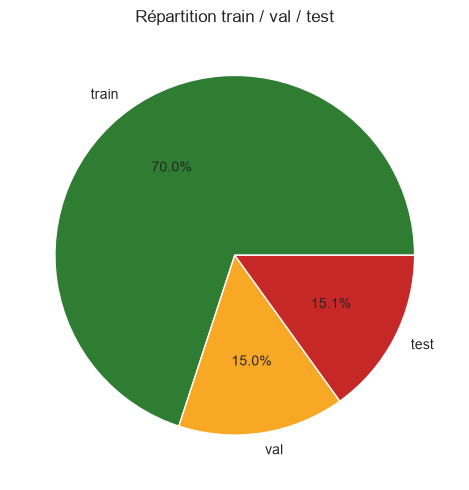

In [19]:
print("Totaux par ensemble :")
print(split_df[["train", "val", "test"]].sum())

totals = split_df[["train", "val", "test"]].sum()
plt.figure(figsize=(5, 5))
plt.pie(totals, labels=totals.index, autopct="%1.1f%%", colors=["#2e7d32", "#f9a825", "#c62828"])
plt.title("Répartition train / val / test")
plt.tight_layout()
plt.savefig(DOCS_DIR / "08_split_train_val_test.png", dpi=150)
plt.show()

## 13. Résumé exécutif et recommandations

In [20]:
print("="*70)
print("RESUME EXECUTIF - EDA PlantVillage")
print("="*70)
print(f"Nombre total d'images        : {len(inventory)}")
print(f"Nombre de classes            : {len(classes)}")
print(f"Nombre de plantes            : {counts_df['plante'].nunique()} ({', '.join(counts_df['plante'].unique())})")
print(f"Taille totale du dataset     : {inventory['taille_octets'].sum() / (1024**2):.1f} MB")
print(f"Images corrompues détectées  : {len(corrupted)}")
print(f"Doublons détectés            : {n_duplicates}")
print(f"Classe la + petite           : {min_row['classe']} ({min_row['nb_images']} images)")
print(f"Classe la + grande           : {max_row['classe']} ({max_row['nb_images']} images)")
print(f"Ratio de déséquilibre        : {ratio:.1f}x")
print(f"% images malades             : {repartition_statut['Malade'] / repartition_statut.sum() * 100:.1f}%")
print("="*70)
print("""
RECOMMANDATIONS POUR P4 (Prétraitement) :
  - Redimensionner toutes les images à une taille fixe (ex. 224x224) avant l'entraînement
  - Supprimer les doublons détectés avant le split train/val/test
  - Exclure ou réparer les images corrompues (si trouvées)

RECOMMANDATIONS POUR P6 (Machine Learning) :
  - Fort déséquilibre entre classes : utiliser class_weight='balanced' et/ou
    de la data augmentation ciblée sur les classes minoritaires (ex. Potato___healthy)
  - Ne jamais évaluer avec l'accuracy seule : privilégier F1-score macro,
    matrice de confusion, précision/rappel par classe
  - Utiliser le split stratifié proposé (section 12) pour garder les proportions
    de chaque classe dans train/val/test

RECOMMANDATIONS POUR P8 (Monitoring, à réutiliser en Sprint 4) :
  - Les statistiques de couleur/luminosité par classe (section 8) serviront
    de référence pour la détection de dérive (drift) en production
""")

RESUME EXECUTIF - EDA PlantVillage
Nombre total d'images        : 20638
Nombre de classes            : 15
Nombre de plantes            : 3 (Tomato, Pepper, Potato)
Taille totale du dataset     : 326.4 MB
Images corrompues détectées  : 0
Doublons détectés            : 14
Classe la + petite           : Potato___healthy (152 images)
Classe la + grande           : Tomato__Tomato_YellowLeaf__Curl_Virus (3208 images)
Ratio de déséquilibre        : 21.1x
% images malades             : 84.4%

RECOMMANDATIONS POUR P4 (Prétraitement) :
  - Redimensionner toutes les images à une taille fixe (ex. 224x224) avant l'entraînement
  - Supprimer les doublons détectés avant le split train/val/test
  - Exclure ou réparer les images corrompues (si trouvées)

RECOMMANDATIONS POUR P6 (Machine Learning) :
  - Fort déséquilibre entre classes : utiliser class_weight='balanced' et/ou
    de la data augmentation ciblée sur les classes minoritaires (ex. Potato___healthy)
  - Ne jamais évaluer avec l'accuracy seule

## 14. Export des résultats

In [21]:
# Export des tableaux pour le rapport final
counts_df.to_csv(DOCS_DIR / "eda_counts_par_classe.csv", index=False)
dims_df.to_csv(DOCS_DIR / "eda_dimensions_echantillon.csv", index=False)
color_summary.to_csv(DOCS_DIR / "eda_couleurs_par_classe.csv")
split_df.to_csv(DOCS_DIR / "eda_split_propose.csv", index=False)

print("Fichiers exportés dans le dossier docs/ :")
for f in sorted(DOCS_DIR.glob("eda_*")):
    print(" -", f.name)
for f in sorted(DOCS_DIR.glob("0*_*.png")):
    print(" -", f.name)

Fichiers exportés dans le dossier docs/ :
 - eda_couleurs_par_classe.csv
 - eda_counts_par_classe.csv
 - eda_dimensions_echantillon.csv
 - eda_split_propose.csv
 - 01_images_per_class.png
 - 02_resolution_distribution.png
 - 03_file_size_distribution.png
 - 04_examples_per_class.png
 - 05_luminosite_par_classe.png
 - 06_healthy_vs_diseased.png
 - 07_repartition_par_plante.png
 - 08_split_train_val_test.png
